# Phase 12 — Deterministic LangGraph RAG Orchestration

This notebook integrates the project’s existing RAG stages into one **fixed**, non-agentic LangGraph workflow. The graph has exactly one forward path:

`START → process_query → retrieve → rerank → build_prompt → generate_answer → format_response → END`

The graph contains no autonomous agent, tool calling, conditional routing, retry loop, retrieval loop, self-correction loop, context grader, or agent decision. LangGraph is used only to orchestrate declared nodes in the declared order.

> **Truthfulness boundary.** The project has real BM25 results, but real BGE-M3 dense/hybrid retrieval is unavailable. Consequently, reranking has no real hybrid candidates, and Qwen2.5-7B-Instruct generation is blocked by both exact-model availability and OpenStax generative-AI permission preflights. The graph still executes every deterministic stage and records these limits rather than manufacturing retrieval, reranking, citations, or answers.


## Learning goals

This notebook demonstrates how a LangGraph state can carry a real question and its progressively enriched fields through a deterministic RAG pipeline. It uses real questions and real BM25 document records from the OpenStax artifact, then exposes the reranking and generation limitations as explicit state updates.

| Node | Deterministic responsibility | Current execution outcome |
| --- | --- | --- |
| process_query | Normalize whitespace only; preserve the user’s language and meaning. | Completes. |
| retrieve | Load the matching real Top-3 BM25 result set. | Completes with real textbook chunks. |
| rerank | Use only real hybrid candidates with the exact BGE reranker. | Explicitly blocked: hybrid candidates do not exist. |
| build_prompt | Assemble the grounded answer contract from **reranked** context only. | Completes with an explicit no-context abstention instruction. |
| generate_answer | Call only Qwen2.5-7B-Instruct after exact-model and permission checks. | Explicitly blocked; no substitute is used. |
| format_response | Package answer, citations, stage statuses, and trace. | Completes without inventing an answer or citation. |


In [1]:
from __future__ import annotations

import json
import operator
import os
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Annotated, Any, TypedDict

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import requests
from IPython.display import Image, Markdown, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = Path("/home/ubuntu/business-knowledge-ai")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
BM25_PATH = PROCESSED_DIR / "introduction_to_business_bm25_retrieval_results.json"
HYBRID_STATUS_PATH = PROCESSED_DIR / "introduction_to_business_hybrid_retrieval_status.json"
RERANK_STATUS_PATH = PROCESSED_DIR / "introduction_to_business_reranking_status.json"
LLM_STATUS_PATH = PROCESSED_DIR / "introduction_to_business_llm_generation_status.json"
RESULTS_PATH = PROCESSED_DIR / "introduction_to_business_langgraph_rag_results.json"
STATUS_PATH = PROCESSED_DIR / "introduction_to_business_langgraph_rag_status.json"
MERMAID_PATH = PROCESSED_DIR / "introduction_to_business_langgraph_rag_flow.mmd"
FLOW_PNG_PATH = PROCESSED_DIR / "introduction_to_business_langgraph_rag_flow.png"

REQUIRED_MODEL = "Qwen2.5-7B-Instruct"
RERANKER_MODEL = "BAAI/bge-reranker-v2-m3"

for required_path in [BM25_PATH, HYBRID_STATUS_PATH, RERANK_STATUS_PATH, LLM_STATUS_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f"Required Phase 12 input is missing: {required_path}")

print("Project root:", PROJECT_ROOT)
print("BM25 artifact:", BM25_PATH)
print("Results artifact:", RESULTS_PATH)


Project root: /home/ubuntu/business-knowledge-ai
BM25 artifact: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_bm25_retrieval_results.json
Results artifact: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_langgraph_rag_results.json


## Inputs and executable preflight

The retrieve node reads the already-executed BM25 artifact. The rerank node reads the Phase 08 status and refuses to score documents unless real hybrid candidates are available. The generation node consults the live model catalog and the explicit OpenStax permission flag before it can make exactly one Qwen request.

This separation matters: **retrieved_documents** may contain real BM25 records, while **reranked_documents** remains empty unless the genuine hybrid-to-reranker path has run.


In [2]:
with BM25_PATH.open("r", encoding="utf-8") as handle:
    bm25_runs = json.load(handle)
with HYBRID_STATUS_PATH.open("r", encoding="utf-8") as handle:
    hybrid_status = json.load(handle)
with RERANK_STATUS_PATH.open("r", encoding="utf-8") as handle:
    rerank_status = json.load(handle)
with LLM_STATUS_PATH.open("r", encoding="utf-8") as handle:
    llm_status = json.load(handle)

def normalize_query(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def query_key(text: str) -> str:
    return normalize_query(text).casefold()

bm25_top3_by_question: dict[str, dict[str, Any]] = {}
for run in bm25_runs:
    if run.get("top_k") == 3:
        bm25_top3_by_question.setdefault(query_key(run["question"]), run)

real_demo_runs = list(bm25_top3_by_question.values())[:2]
if len(real_demo_runs) < 2:
    raise RuntimeError("Phase 12 needs at least two real Top-3 BM25 question runs.")

def permission_confirmed() -> bool:
    value = os.getenv("OPENSTAX_GENERATIVE_AI_PERMISSION_CONFIRMED", "")
    return value.strip().lower() in {"1", "true", "yes", "confirmed"}

def live_exact_model_available() -> tuple[bool, list[str], str | None]:
    base_url = os.getenv("OPENAI_API_BASE", "").rstrip("/")
    api_key = os.getenv("OPENAI_API_KEY", "")
    if not base_url or not api_key:
        return False, [], "OPENAI_API_BASE or OPENAI_API_KEY is not available."
    try:
        response = requests.get(
            f"{base_url}/models",
            headers={"Authorization": f"Bearer {api_key}"},
            timeout=20,
        )
        response.raise_for_status()
        payload = response.json()
        model_ids = [item.get("id", "") for item in payload.get("data", [])]
        matches = [model_id for model_id in model_ids if model_id == REQUIRED_MODEL]
        return bool(matches), matches, None
    except requests.RequestException as exc:
        return False, [], f"Model catalog check failed: {type(exc).__name__}: {exc}"

exact_model_available, matching_model_ids, catalog_error = live_exact_model_available()
openstax_permission = permission_confirmed()

preflight = {
    "retrieval_type": "BM25 only",
    "bm25_artifact_real": hybrid_status["bm25"]["status"] == "completed_on_real_phase_03_chunks",
    "dense_retrieval_ready": hybrid_status["dense_retrieval_ready"],
    "hybrid_retrieval_ready": hybrid_status["hybrid"]["status"] == "completed",
    "reranking_ready": rerank_status["reranking_ready"],
    "exact_model_available": exact_model_available,
    "matching_model_ids": matching_model_ids,
    "openstax_generative_ai_permission_confirmed": openstax_permission,
    "catalog_error": catalog_error,
}

display(Markdown("### Phase 12 preflight"))
print(json.dumps(preflight, indent=2))
print("Real demo questions:")
for index, run in enumerate(real_demo_runs, start=1):
    print(f"{index}. {run['question']}")


### Phase 12 preflight

{
  "retrieval_type": "BM25 only",
  "bm25_artifact_real": true,
  "dense_retrieval_ready": false,
  "hybrid_retrieval_ready": false,
  "reranking_ready": false,
  "exact_model_available": false,
  "matching_model_ids": [],
  "openstax_generative_ai_permission_confirmed": false,
  "catalog_error": null
}
Real demo questions:
1. What role do businesses play in an economy?
2. What factors should an entrepreneur consider when choosing a business ownership structure?


## Graph visualization

The Mermaid source below is the authoritative graph specification. A deterministic PNG is also generated from the same ordered node list and displayed for convenient notebook review. There are no conditional edges: every question moves through the same six nodes exactly once.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


~~~mermaid
flowchart TD
    S([START]) --> A[process_query]
    A --> B[retrieve]
    B --> C[rerank]
    C --> D[build_prompt]
    D --> E[generate_answer]
    E --> F[format_response]
    F --> T([END])
~~~

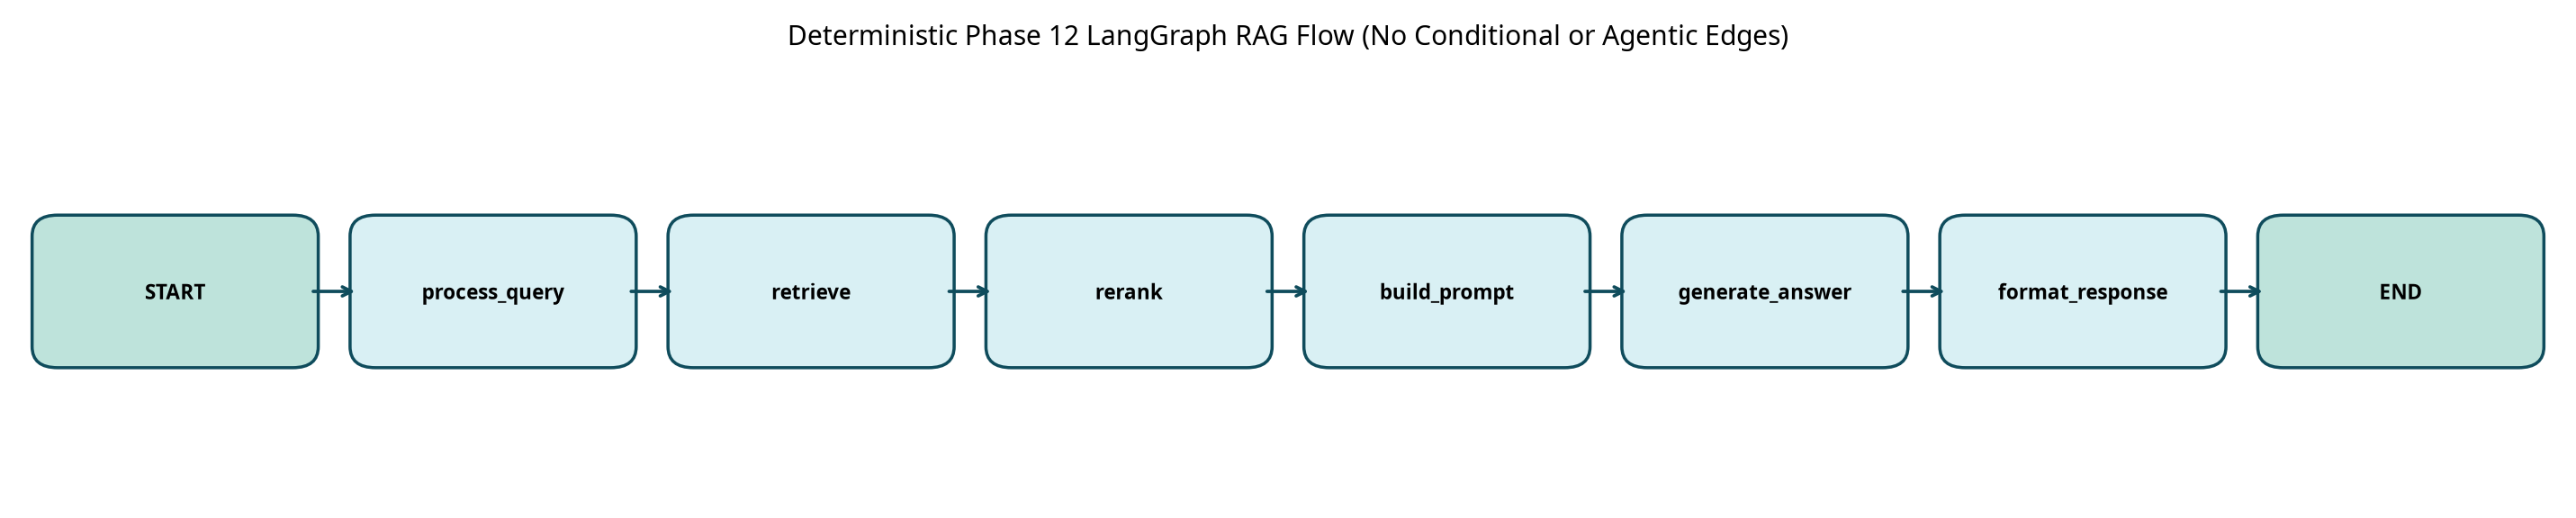

Saved Mermaid source: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_langgraph_rag_flow.mmd
Saved visualization: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_langgraph_rag_flow.png


In [3]:
MERMAID_SOURCE = """flowchart TD
    S([START]) --> A[process_query]
    A --> B[retrieve]
    B --> C[rerank]
    C --> D[build_prompt]
    D --> E[generate_answer]
    E --> F[format_response]
    F --> T([END])
"""
MERMAID_PATH.write_text(MERMAID_SOURCE, encoding="utf-8")

ordered_labels = ["START", "process_query", "retrieve", "rerank", "build_prompt", "generate_answer", "format_response", "END"]
fig, ax = plt.subplots(figsize=(16, 3.3))
ax.set_xlim(-0.5, len(ordered_labels) - 0.5)
ax.set_ylim(-0.8, 0.8)
ax.axis("off")
for index, label in enumerate(ordered_labels):
    is_terminal = label in {"START", "END"}
    patch = FancyBboxPatch(
        (index - 0.42, -0.26),
        0.84,
        0.52,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.4,
        edgecolor="#0F4C5C",
        facecolor="#D9F0F4" if not is_terminal else "#BEE3DB",
    )
    ax.add_patch(patch)
    ax.text(index, 0, label, ha="center", va="center", fontsize=9, fontweight="bold")
    if index < len(ordered_labels) - 1:
        ax.annotate(
            "",
            xy=(index + 0.58, 0),
            xytext=(index + 0.42, 0),
            arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#0F4C5C"},
        )
ax.set_title("Deterministic Phase 12 LangGraph RAG Flow (No Conditional or Agentic Edges)", fontsize=12, pad=16)
fig.tight_layout()
fig.savefig(FLOW_PNG_PATH, dpi=180, bbox_inches="tight")
plt.close(fig)

display(Markdown("~~~mermaid\n" + MERMAID_SOURCE + "~~~"))
display(Image(filename=str(FLOW_PNG_PATH)))
print("Saved Mermaid source:", MERMAID_PATH)
print("Saved visualization:", FLOW_PNG_PATH)


## State contract

The state tracks both content fields and auditable stage metadata. The **stage_trace** reducer appends one immutable event per node, which makes the graph’s forward-only transitions visible after execution.

The state contains the requested core fields: question, rewritten_query, retrieved_documents, reranked_documents, prompt, answer, and citations. The rewritten query is deliberately only whitespace-normalized; it is not an LLM rewrite and does not alter meaning.


In [4]:
class DeterministicRAGState(TypedDict, total=False):
    question: str
    user_language: str
    rewritten_query: str
    retrieved_documents: list[dict[str, Any]]
    reranked_documents: list[dict[str, Any]]
    prompt: str
    answer: str | None
    citations: list[dict[str, Any]]
    retrieval_status: str
    reranking_status: str
    generation_status: str
    response: dict[str, Any]
    stage_trace: Annotated[list[dict[str, Any]], operator.add]

def trace_event(node: str, status: str, **details: Any) -> dict[str, Any]:
    return {
        "node": node,
        "status": status,
        "details": details,
    }

def document_citations(documents: list[dict[str, Any]]) -> list[dict[str, Any]]:
    return [
        {
            "chunk_id": document["chunk_id"],
            "page": document["page"],
            "chapter": document["chapter"],
            "section": document.get("section"),
            "source_title": document["source"]["title"],
            "official_book_url": document["source"]["official_book_url"],
        }
        for document in documents
    ]

def process_query(state: DeterministicRAGState) -> dict[str, Any]:
    normalized = normalize_query(state["question"])
    return {
        "rewritten_query": normalized,
        "stage_trace": [trace_event(
            "process_query",
            "completed",
            transformation="whitespace normalization only; no LLM rewrite",
            rewritten_query=normalized,
        )],
    }

def retrieve(state: DeterministicRAGState) -> dict[str, Any]:
    selected = bm25_top3_by_question.get(query_key(state["rewritten_query"]))
    if selected is None:
        return {
            "retrieved_documents": [],
            "retrieval_status": "no_exact_precomputed_bm25_question_match",
            "stage_trace": [trace_event(
                "retrieve",
                "completed_without_documents",
                source="real BM25 artifact",
                reason="The notebook only demonstrates questions already executed in the real BM25 artifact.",
            )],
        }
    documents = selected["results"]
    return {
        "retrieved_documents": documents,
        "retrieval_status": "completed_real_bm25_top3",
        "stage_trace": [trace_event(
            "retrieve",
            "completed",
            retrieval_type="BM25 only",
            document_count=len(documents),
            chunk_ids=[document["chunk_id"] for document in documents],
        )],
    }

def rerank(state: DeterministicRAGState) -> dict[str, Any]:
    # This graph intentionally refuses to relabel BM25-only records as reranked context.
    # The exact BGE reranker path is enabled only when real hybrid candidates exist.
    if not rerank_status["reranking_ready"] or not hybrid_status["hybrid_retrieval_ready"]:
        return {
            "reranked_documents": [],
            "reranking_status": "blocked_missing_real_hybrid_candidates",
            "stage_trace": [trace_event(
                "rerank",
                "blocked",
                reranker_model=RERANKER_MODEL,
                retrieved_document_count=len(state.get("retrieved_documents", [])),
                reason=rerank_status["limitation"],
            )],
        }

    # This guarded branch is deliberately deterministic: score the provided hybrid candidates once,
    # sort descending by score, and select the configured Top-K. It is not reached in this environment.
    from FlagEmbedding import FlagReranker
    reranker = FlagReranker(RERANKER_MODEL, use_fp16=False)
    candidates = state.get("retrieved_documents", [])[: rerank_status["top_n_candidates"]]
    pairs = [[state["rewritten_query"], document["text"]] for document in candidates]
    scores = reranker.compute_score(pairs, batch_size=8)
    scored = []
    for document, score in zip(candidates, scores):
        enriched = dict(document)
        enriched["reranker_score"] = float(score)
        scored.append(enriched)
    ordered = sorted(scored, key=lambda item: item["reranker_score"], reverse=True)
    final_context = ordered[: rerank_status["top_k_final_context"]]
    return {
        "reranked_documents": final_context,
        "reranking_status": "completed_exact_bge_reranker",
        "stage_trace": [trace_event(
            "rerank",
            "completed",
            reranker_model=RERANKER_MODEL,
            candidate_count=len(candidates),
            selected_count=len(final_context),
        )],
    }

def build_prompt(state: DeterministicRAGState) -> dict[str, Any]:
    documents = state.get("reranked_documents", [])
    if documents:
        context_block = "\n\n".join(
            "[Source {index} | page {page} | chunk {chunk}]\n{text}".format(
                index=index,
                page=document["page"],
                chunk=document["chunk_id"],
                text=document["text"],
            )
            for index, document in enumerate(documents, start=1)
        )
    else:
        context_block = "NO RERANKED CONTEXT AVAILABLE. Do not answer from background knowledge."

    prompt = """You are Business Knowledge AI. Answer only from the RERANKED CONTEXT below.
Rules:
1. Do not make unsupported claims or use background knowledge.
2. If the context is insufficient or unavailable, say that the textbook context is insufficient.
3. Cite each supported claim using the provided page and chunk labels.
4. Answer in the user's language: {language}.
5. Do not mention tools, agents, hidden reasoning, or autonomous decisions.

Question: {question}

RERANKED CONTEXT:
{context}
""".format(
        language=state["user_language"],
        question=state["question"],
        context=context_block,
    )
    return {
        "prompt": prompt,
        "stage_trace": [trace_event(
            "build_prompt",
            "completed",
            reranked_document_count=len(documents),
            prompt_requires_abstention=not bool(documents),
        )],
    }

def generate_answer(state: DeterministicRAGState) -> dict[str, Any]:
    reasons = []
    if not exact_model_available:
        reasons.append(f"Exact model {REQUIRED_MODEL} is not available in the live catalog.")
    if not openstax_permission:
        reasons.append("OpenStax generative-AI permission is not explicitly confirmed.")
    if not state.get("reranked_documents"):
        reasons.append("No real reranked context is available for grounded generation.")

    if reasons:
        return {
            "answer": None,
            "generation_status": "blocked_exact_model_permission_or_context_preflight",
            "stage_trace": [trace_event(
                "generate_answer",
                "blocked",
                model=REQUIRED_MODEL,
                reasons=reasons,
            )],
        }

    # This is the only allowed generation path: one exact-model call, no tools, no retries,
    # no self-correction, and no route changes. It remains unexecuted under the current preflight.
    from openai import OpenAI
    client = OpenAI()
    completion = client.chat.completions.create(
        model=REQUIRED_MODEL,
        messages=[
            {"role": "system", "content": "Follow the user prompt exactly and remain evidence-bounded."},
            {"role": "user", "content": state["prompt"]},
        ],
        temperature=0.0,
        max_tokens=320,
    )
    answer = completion.choices[0].message.content
    return {
        "answer": answer,
        "generation_status": "completed_exact_qwen_single_call",
        "stage_trace": [trace_event(
            "generate_answer",
            "completed",
            model=REQUIRED_MODEL,
            temperature=0.0,
            max_tokens=320,
        )],
    }

def format_response(state: DeterministicRAGState) -> dict[str, Any]:
    citations = document_citations(state.get("reranked_documents", []))
    response = {
        "question": state["question"],
        "answer": state.get("answer"),
        "citations": citations,
        "retrieval_status": state.get("retrieval_status"),
        "reranking_status": state.get("reranking_status"),
        "generation_status": state.get("generation_status"),
        "message": (
            "No answer was generated because the deterministic preflight did not permit the exact grounded generation path."
            if state.get("answer") is None
            else "Answer generated through the fixed deterministic path."
        ),
    }
    return {
        "citations": citations,
        "response": response,
        "stage_trace": [trace_event(
            "format_response",
            "completed",
            answer_present=state.get("answer") is not None,
            citation_count=len(citations),
        )],
    }


## Build the fixed StateGraph

Each edge is declared once and points forward. The graph has no conditional router and no loop edge. A MemorySaver checkpointer is attached solely to inspect persisted state snapshots and is not used to alter future retrieval or generation behavior.


In [5]:
builder = StateGraph(DeterministicRAGState)
builder.add_node("process_query", process_query)
builder.add_node("retrieve", retrieve)
builder.add_node("rerank", rerank)
builder.add_node("build_prompt", build_prompt)
builder.add_node("generate_answer", generate_answer)
builder.add_node("format_response", format_response)

builder.add_edge(START, "process_query")
builder.add_edge("process_query", "retrieve")
builder.add_edge("retrieve", "rerank")
builder.add_edge("rerank", "build_prompt")
builder.add_edge("build_prompt", "generate_answer")
builder.add_edge("generate_answer", "format_response")
builder.add_edge("format_response", END)

checkpointer = MemorySaver()
rag_graph = builder.compile(checkpointer=checkpointer)

print("Compiled deterministic graph.")
print("Declared nodes:", ["process_query", "retrieve", "rerank", "build_prompt", "generate_answer", "format_response"])
print("Declared edge count: 7 (START + six forward transitions + END)")


Compiled deterministic graph.
Declared nodes: ['process_query', 'retrieve', 'rerank', 'build_prompt', 'generate_answer', 'format_response']
Declared edge count: 7 (START + six forward transitions + END)


## Run real textbook questions and inspect state transitions

The inputs below are questions already present in the real BM25 retrieval artifact. Each invocation reaches every node exactly once. The retrieved state therefore contains real OpenStax chunks, while the rerank and generate stages record their verified blocks. No answer text or citation is synthesized in the blocked state.


In [6]:
executions: list[dict[str, Any]] = []
for index, run in enumerate(real_demo_runs, start=1):
    question = run["question"]
    thread_id = f"phase12-real-question-{index}"
    config = {"configurable": {"thread_id": thread_id}}
    initial_state: DeterministicRAGState = {
        "question": question,
        "user_language": "English",
        "stage_trace": [],
    }
    final_state = rag_graph.invoke(initial_state, config=config)
    snapshots = list(rag_graph.get_state_history(config))

    assert final_state["retrieval_status"] == "completed_real_bm25_top3"
    assert len(final_state["retrieved_documents"]) == 3
    assert final_state["reranking_status"] == "blocked_missing_real_hybrid_candidates"
    assert final_state["reranked_documents"] == []
    assert final_state["generation_status"] == "blocked_exact_model_permission_or_context_preflight"
    assert final_state["answer"] is None
    assert final_state["citations"] == []
    assert [event["node"] for event in final_state["stage_trace"]] == [
        "process_query",
        "retrieve",
        "rerank",
        "build_prompt",
        "generate_answer",
        "format_response",
    ]

    execution = {
        "thread_id": thread_id,
        "question": question,
        "rewritten_query": final_state["rewritten_query"],
        "retrieved_document_count": len(final_state["retrieved_documents"]),
        "retrieved_chunk_ids": [document["chunk_id"] for document in final_state["retrieved_documents"]],
        "reranked_document_count": len(final_state["reranked_documents"]),
        "answer": final_state["answer"],
        "citation_count": len(final_state["citations"]),
        "response": final_state["response"],
        "stage_trace": final_state["stage_trace"],
        "checkpoint_snapshot_count": len(snapshots),
    }
    executions.append(execution)

    display(Markdown(f"### Real question {index}: {question}"))
    print("Retrieved chunks:", execution["retrieved_chunk_ids"])
    print("Stage trace:")
    for event in execution["stage_trace"]:
        print(f"- {event['node']}: {event['status']}")
    print("Final response:")
    print(json.dumps(execution["response"], indent=2))
    print("Checkpoint snapshots:", execution["checkpoint_snapshot_count"])

assert len(executions) == 2
assert all(item["retrieved_document_count"] == 3 for item in executions)
assert all(item["answer"] is None for item in executions)
assert all(item["citation_count"] == 0 for item in executions)


### Real question 1: What role do businesses play in an economy?

Retrieved chunks: ['openstax-introduction-business-p0193-c001', 'openstax-introduction-business-p0157-c002', 'openstax-introduction-business-p0216-c001']
Stage trace:
- process_query: completed
- retrieve: completed
- rerank: blocked
- build_prompt: completed
- generate_answer: blocked
- format_response: completed
Final response:
{
  "question": "What role do businesses play in an economy?",
  "answer": null,
  "citations": [],
  "retrieval_status": "completed_real_bm25_top3",
  "reranking_status": "blocked_missing_real_hybrid_candidates",
  "generation_status": "blocked_exact_model_permission_or_context_preflight",
  "message": "No answer was generated because the deterministic preflight did not permit the exact grounded generation path."
}
Checkpoint snapshots: 8


### Real question 2: What factors should an entrepreneur consider when choosing a business ownership structure?

Retrieved chunks: ['openstax-introduction-business-p0170-c001', 'openstax-introduction-business-p0277-c002', 'openstax-introduction-business-p0141-c001']
Stage trace:
- process_query: completed
- retrieve: completed
- rerank: blocked
- build_prompt: completed
- generate_answer: blocked
- format_response: completed
Final response:
{
  "question": "What factors should an entrepreneur consider when choosing a business ownership structure?",
  "answer": null,
  "citations": [],
  "retrieval_status": "completed_real_bm25_top3",
  "reranking_status": "blocked_missing_real_hybrid_candidates",
  "generation_status": "blocked_exact_model_permission_or_context_preflight",
  "message": "No answer was generated because the deterministic preflight did not permit the exact grounded generation path."
}
Checkpoint snapshots: 8


## Interpretation

The graph proves that the orchestration is operational: each real question progresses through the same six nodes and the trace captures each transition. The retrieve node contributes real BM25 records. The graph deliberately does **not** reinterpret those BM25 records as hybrid candidates or reranked context, so the rerank node blocks honestly. Because no real reranked context, exact model, and confirmed permission are simultaneously available, generation remains blocked and the final formatter returns no answer or citations.

When the prerequisites become available, the existing guarded branches will run the exact reranker once and Qwen once, while retaining the same graph topology. They will not introduce routing decisions, loops, agents, tools, or self-correction.


In [7]:
results = {
    "phase": "12_langgraph_rag",
    "workflow": [
        "START",
        "process_query",
        "retrieve",
        "rerank",
        "build_prompt",
        "generate_answer",
        "format_response",
        "END",
    ],
    "graph_type": "fixed_forward_stategraph",
    "preflight": preflight,
    "graph_visualization": {
        "mermaid_path": str(MERMAID_PATH.relative_to(PROJECT_ROOT)),
        "png_path": str(FLOW_PNG_PATH.relative_to(PROJECT_ROOT)),
    },
    "executions": executions,
    "scope": "Deterministic LangGraph RAG orchestration only; no autonomous agents, tool calling, retrieval loops, self-correction, context grading, or agent decisions.",
}
with RESULTS_PATH.open("w", encoding="utf-8") as handle:
    json.dump(results, handle, indent=2, ensure_ascii=False)

status = {
    "phase": "12_langgraph_rag",
    "langgraph_installed": True,
    "notebook_executed": True,
    "fixed_workflow_executed": True,
    "real_question_execution_count": len(executions),
    "real_bm25_retrieval_executed": all(item["retrieved_document_count"] == 3 for item in executions),
    "dense_retrieval_executed": False,
    "hybrid_retrieval_executed": False,
    "reranking_executed": False,
    "exact_qwen_generation_executed": False,
    "citations_generated": False,
    "reranking_status": rerank_status["status"],
    "generation_status": llm_status["status"],
    "openstax_generative_ai_permission_confirmed": openstax_permission,
    "exact_model_available": exact_model_available,
    "autonomous_agents_implemented": False,
    "tool_calling_implemented": False,
    "retrieval_loops_implemented": False,
    "self_correction_loops_implemented": False,
    "context_grading_implemented": False,
    "agent_decisions_implemented": False,
    "results_artifact": str(RESULTS_PATH.relative_to(PROJECT_ROOT)),
    "graph_mermaid_artifact": str(MERMAID_PATH.relative_to(PROJECT_ROOT)),
    "graph_png_artifact": str(FLOW_PNG_PATH.relative_to(PROJECT_ROOT)),
    "status": "completed_with_verified_rerank_and_generation_limitations",
    "limitation": "The fixed graph executed over two real BM25 questions, but no final reranked context or answer was produced because real hybrid candidates are unavailable and the exact Qwen plus OpenStax permission preflight is not satisfied. No substitute, fabricated reranking, fabricated citation, or fabricated answer was used.",
    "executed_at_utc": datetime.now(timezone.utc).isoformat(),
}
with STATUS_PATH.open("w", encoding="utf-8") as handle:
    json.dump(status, handle, indent=2, ensure_ascii=False)

print("Saved results:", RESULTS_PATH)
print("Saved status:", STATUS_PATH)
print(json.dumps(status, indent=2))


Saved results: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_langgraph_rag_results.json
Saved status: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_langgraph_rag_status.json
{
  "phase": "12_langgraph_rag",
  "langgraph_installed": true,
  "notebook_executed": true,
  "fixed_workflow_executed": true,
  "real_question_execution_count": 2,
  "real_bm25_retrieval_executed": true,
  "dense_retrieval_executed": false,
  "hybrid_retrieval_executed": false,
  "reranking_executed": false,
  "exact_qwen_generation_executed": false,
  "citations_generated": false,
  "reranking_status": "blocked_missing_real_hybrid_candidates",
  "generation_status": "blocked_exact_model_or_permission_preflight",
  "openstax_generative_ai_permission_confirmed": false,
  "exact_model_available": false,
  "autonomous_agents_implemented": false,
  "tool_calling_implemented": false,
  "retrieval_loops_implemented": false,
  "self_correction_loops_implemented":